# EUR/USD Mean Reversion Strategy
### Spot FX vs 6E Futures Backtest

This notebook compares a simple Bollinger Band + slope mean reversion strategy on:
- EUR/USD spot FX (IBKR)
- 6E CME Futures

All backtests and metrics are built from scratch in Python.


In [9]:
import pandas as pd

df_spot = pd.read_csv("data/EURUSD_IBKR.csv", parse_dates=["date"])
df_spot.set_index("date", inplace=True)
df_spot.head()


,open,high,low,close,volume,average,barCount
date,,,,,,,
2005-05-30,1.2536,1.25460,1.2466,1.24760,-1.0,-1.0,-1
2005-05-31,1.2476,1.24870,1.2296,1.23030,-1.0,-1.0,-1
2005-06-01,1.2308,1.23410,1.2159,1.21790,-1.0,-1.0,-1
2005-06-02,1.2205,1.22975,1.2182,1.22660,-1.0,-1.0,-1
2005-06-03,1.2275,1.23430,1.2205,1.22345,-1.0,-1.0,-1


In [11]:
from strategies.mean_reversion import apply_mean_reversion_strategy

df_spot = apply_mean_reversion_strategy(df_spot, window=8, slope_window=3)


In [13]:
from utils.backtest_engine import simulate_trades

df_spot = simulate_trades(df_spot)


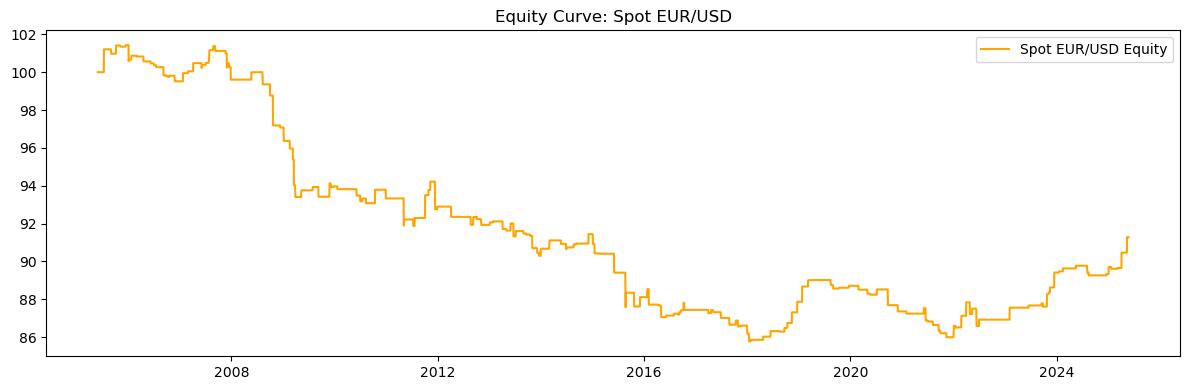

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_spot["equity"], label="Spot EUR/USD Equity", color="orange")
plt.title("Equity Curve: Spot EUR/USD")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
total_return = df_spot['equity'].iloc[-1] / 100 - 1
num_years = (df_spot.index[-1] - df_spot.index[0]).days / 365.25
cagr = (df_spot['equity'].iloc[-1] / 100) ** (1 / num_years) - 1
sharpe = df_spot['strategy_returns'].mean() / df_spot['strategy_returns'].std() * (252 ** 0.5)
max_dd = ((df_spot['equity'].cummax() - df_spot['equity']) / df_spot['equity'].cummax()).max()

print(f"📊 Spot EUR/USD Performance")
print(f"Total Return: {total_return:.2%}")
print(f"CAGR: {cagr:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")


📊 Spot EUR/USD Performance
Total Return: -8.72%
CAGR: -0.46%
Sharpe: -0.29
Max Drawdown: 15.44%
